In [60]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Polars:", pl.__version__)
print("NumPy:", np.__version__)

Polars: 1.44.2
NumPy: 2.5.3


# Carga de los Datos Crudos

In [61]:
from pathlib import Path
import sys

RUTA_PROYECTO = Path.cwd().parent
sys.path.append(str(RUTA_PROYECTO))

In [62]:
from config.rutas import (
    RUTA_PROYECTO,
    RUTA_DATA_RAW,
    RUTA_DATA_PROCESSED,
    RUTA_ENDIREH_CSV,
)

df_crudo = pl.read_csv(RUTA_ENDIREH_CSV)


# Exploracion inicial

Antes de realizar el análisis exploratorio y calcular las medidas descriptivas, se realiza una revisión de la calidad de los datos.

El preprocesamiento contempla:

- revisión de la estructura del dataset;
- identificación de valores faltantes;
- revisión de los tipos de datos;
- identificación de posibles códigos especiales;

In [63]:
print(f"Número de filas: {df_crudo.height}")
print(f"Número de columnas: {df_crudo.width}")

Número de filas: 110127
Número de columnas: 24


In [64]:
#Revisamos los nombres  y tipos de datos de las columnas
df_crudo.schema

Schema([('cve_entidad', Int64),
        ('nom_entidad', String),
        ('cve_municipio', Int64),
        ('nom_municipio', String),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad', String),
        ('estado_civil_id', Int64),
        ('estado_civil_desc', String),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Int64),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Int64),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Int64),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Int64),
        ('tiene_ahorros_desc', String),
        ('propietaria_vivienda_id', Int64),
        ('propietaria_vivienda_desc', String),
        ('sufrio_violencia_pareja', Int64),
        ('factor_expansion', Int64),
        ('anio_encuesta', Int64)])

In [65]:
# Detectamos valores nulos
resumen_nulos = pl.DataFrame({
    "variable": df_crudo.columns,
    "nulos": [
        df_crudo[columna].null_count()
        for columna in df_crudo.columns
    ]
})


resumen_nulos.filter(
    pl.col("nulos") > 0
).sort(
    "nulos",
    descending=True
)

variable,nulos
str,i64
"""edad_primer_union""",85567
"""ingreso_pareja""",61147
"""num_hijos""",19436


In [ ]:
# Detectamos filas completamente idénticas
duplicados_exactos = df_crudo.is_duplicated().sum()

print(
    f"Filas completamente idénticas detectadas: "
    f"{duplicados_exactos}"
)


Filas completamente idénticas detectadas: 7882


In [67]:
# Revisamos valores únicos de variables importantes
# Revisamos cuantas mujeres han sufrido violencia por parte de su pareja
df_crudo.group_by(
    "sufrio_violencia_pareja"
).len().sort(
    "sufrio_violencia_pareja"
)


sufrio_violencia_pareja,len
i64,u32
0,90821
1,19306


In [68]:
# Revisamos el nivel de escolaridad de las mujeres encuestadas
df_crudo.group_by(
    "nivel_escolaridad"
).len().sort(
    "len",
    descending=True
)

nivel_escolaridad,len
str,u32
"""A1""",66131
"""C1""",14587
"""B1""",12598
"""B2""",9553
"""C2""",4849
"""A2""",2409


In [69]:
# Revisamos el estado civil de las mujeres encuestadas
df_crudo.group_by(
    "estado_civil_desc"
).len().sort(
    "len",
    descending=True
)

estado_civil_desc,len
str,u32
"""Casada""",44977
"""Unión libre""",23597
"""Soltera""",20002
"""Viuda""",9750
"""Separada""",8628
"""Divorciada""",3173


In [70]:
# Revisamos la edad de primer unión de las mujeres encuestadas
df_crudo.group_by(
    "edad_primer_union"
).len().sort(
    "edad_primer_union"
)

edad_primer_union,len
f64,u32
null,85567
0.0,3478
1.0,2015
2.0,1740
3.0,1487
…,…
72.0,1
74.0,1
76.0,1


In [71]:
# Revisamos el número de hijos de las mujeres encuestadas
df_crudo.group_by(
    "num_hijos"
).len().sort(
    "num_hijos"
)

num_hijos,len
f64,u32
null,19436
1.0,31398
2.0,2115
3.0,36019
4.0,21159


In [72]:
# Revisamos el ingreso de la pareja de las mujeres encuestadas
df_crudo.select(
    "ingreso_pareja"
).drop_nulls().sort(
    "ingreso_pareja",
    descending=True
).head(20)

ingreso_pareja
f64
9.99999e5
9.99999e5
9.99999e5
9.99999e5
9.99999e5
…
9.99999e5
9.99999e5
9.99999e5


In [73]:
df_crudo.filter(
    pl.col("edad_primer_union").is_in([0, 1, 2, 3, 98, 99])
).group_by(
    "edad_primer_union"
).len()

edad_primer_union,len
f64,u32
3.0,1487
1.0,2015
0.0,3478
2.0,1740
98.0,656
99.0,227


# Preprocesamiento de los datos
A partir de la exploración inicial se identificaron valores faltante y variables cuyo tipo de dato debe revisarse.

In [74]:
df = df_crudo.clone()

In [ ]:
# Normalizamos variables de texto
columnas_texto = [
    columna
    for columna, tipo in df.schema.items()
    if tipo == pl.String
]

# Quitamos espacios en blanco al inicio y final de las cadenas de texto
df = df.with_columns([
    pl.col(columna)
    .str.strip_chars()
    .alias(columna)

    for columna in columnas_texto
])

# Reemplazamos cadenas vacías por valores nulos
df = df.with_columns([
    pl.when(
        pl.col(columna) == ""
    )
    .then(None)
    .otherwise(
        pl.col(columna)
    )
    .alias(columna)

    for columna in columnas_texto
])

In [ ]:
#Corregimos tipos de datos
df = df.with_columns([
    pl.col("edad_primer_union")
    .cast(pl.Int64, strict=False),

    pl.col("num_hijos")
    .cast(pl.Int64, strict=False),

    pl.col("sufrio_violencia_pareja")
    .cast(pl.Int8),

    pl.col("anio_encuesta")
    .cast(pl.Int16)
])



In [78]:
# Las edades de primer unión válidas son entre 10 y 97 años, por lo que reemplazamos los valores fuera de este rango por nulos
df = df.with_columns(
    pl.when(
        pl.col("edad_primer_union").is_between(10, 97)
    )
    .then(
        pl.col("edad_primer_union")
    )
    .otherwise(None)
    .alias("edad_primer_union")
)

In [79]:
# Guardamos el DataFrame limpio en un archivo CSV
RUTA_SALIDA = RUTA_DATA_PROCESSED / "endireh_2021_limpio.csv"

df.write_csv(RUTA_SALIDA)

print(f"Archivo guardado en: {RUTA_SALIDA}")

Archivo guardado en: /home/diegovega/Universidad/Semestre_7/Almacenes_Mineria_De_Datos/Practicas/proyecto-endireh-violencia/data/data-processed/endireh_2021_limpio.csv


# Aanalisis Exploratorio de Datos

## Distribución de violencia de pareja


In [80]:
# Distribución de violencia de pareja
violencia = (
    df.group_by("sufrio_violencia_pareja")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("sufrio_violencia_pareja")
)

violencia

sufrio_violencia_pareja,len,porcentaje
i8,u32,f64
0,90821,82.47
1,19306,17.53


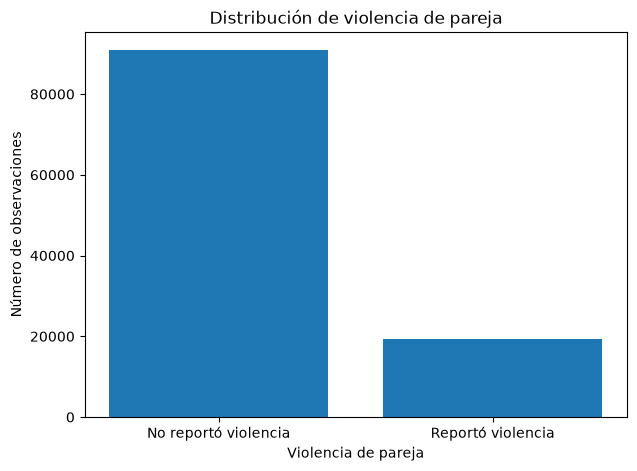

In [81]:
violencia_plot = violencia.sort("sufrio_violencia_pareja")

categorias = [
    "No reportó violencia",
    "Reportó violencia"
]

frecuencias = violencia_plot["len"].to_list()

plt.figure(figsize=(7, 5))
plt.bar(categorias, frecuencias)

plt.title("Distribución de violencia de pareja")
plt.ylabel("Número de observaciones")
plt.xlabel("Violencia de pareja")

plt.show()

## Nivel de escolaridad

In [82]:
escolaridad = (
    df.group_by("nivel_escolaridad")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("len", descending=True)
)

escolaridad

nivel_escolaridad,len,porcentaje
str,u32,f64
"""A1""",66131,60.05
"""C1""",14587,13.25
"""B1""",12598,11.44
"""B2""",9553,8.67
"""C2""",4849,4.4
"""A2""",2409,2.19


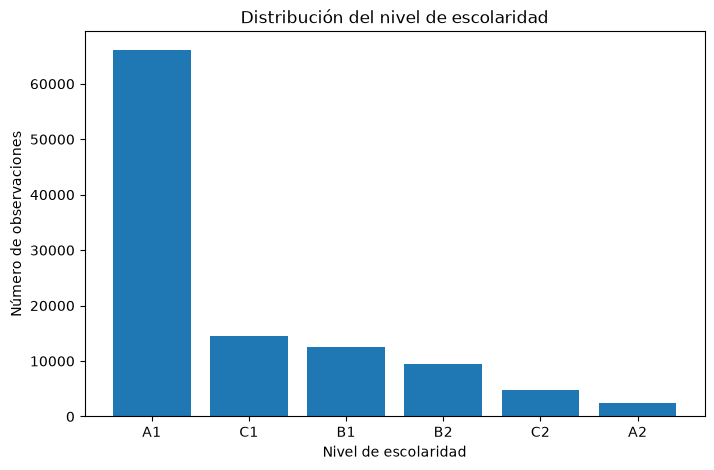

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    escolaridad["nivel_escolaridad"].to_list(),
    escolaridad["len"].to_list()
)

plt.title("Distribución del nivel de escolaridad")
plt.xlabel("Nivel de escolaridad")
plt.ylabel("Número de observaciones")

plt.show()

## Estado civil

In [57]:
estado_civil = (
    df.group_by("estado_civil_desc")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("len", descending=True)
)

estado_civil

estado_civil_desc,len,porcentaje
str,u32,f64
"""Casada""",44977,40.84
"""Unión libre""",23597,21.43
"""Soltera""",20002,18.16
"""Viuda""",9750,8.85
"""Separada""",8628,7.83
"""Divorciada""",3173,2.88


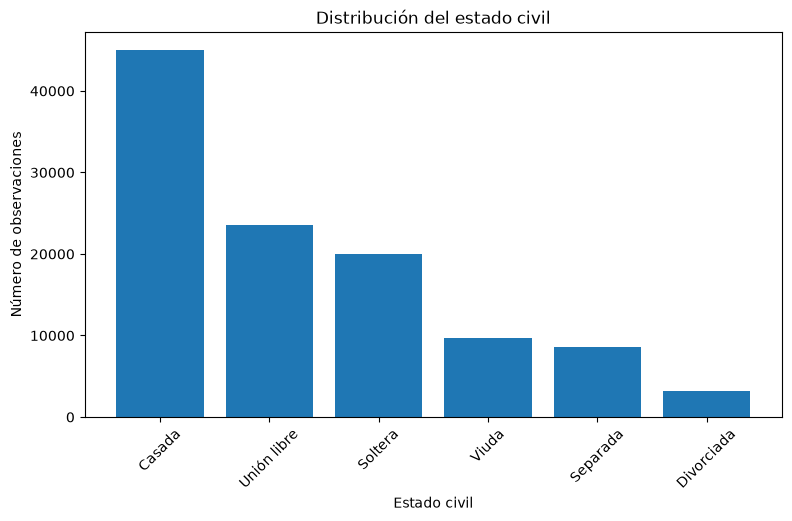

In [58]:
plt.figure(figsize=(9, 5))

plt.bar(
    estado_civil["estado_civil_desc"].to_list(),
    estado_civil["len"].to_list()
)

plt.title("Distribución del estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Número de observaciones")

plt.xticks(rotation=45)

plt.show()

## Distribución de edad_primer_union

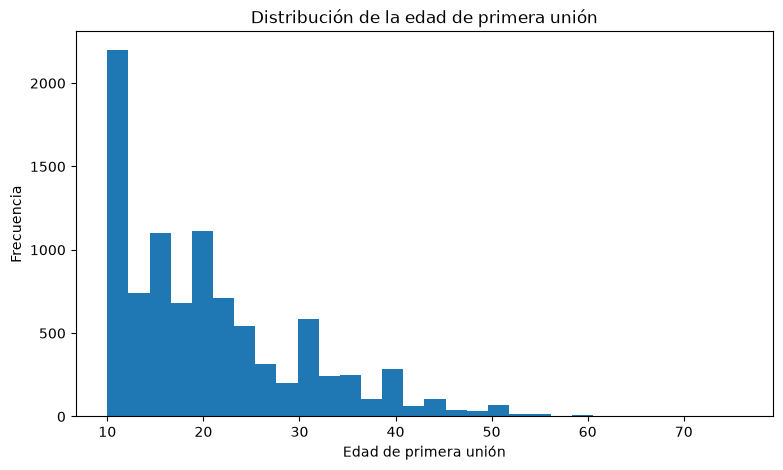

In [59]:
edades = (
    df.select("edad_primer_union")
    .drop_nulls()
    ["edad_primer_union"]
    .to_numpy()
)

plt.figure(figsize=(9, 5))

plt.hist(
    edades,
    bins=30
)

plt.title("Distribución de la edad de primera unión")
plt.xlabel("Edad de primera unión")
plt.ylabel("Frecuencia")

plt.show()